In [8]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, f_oneway, chi2_contingency

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [9]:
# Step 2: Load dataset
file_path = "seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [10]:
# Step 3: Understand the dataset structure
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.dtypes.to_frame("Data Type"))

print("\nUnique values in categorical columns:")
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()}")
        print(df[col].value_counts())
        print()

Rows: 4000
Columns: 28


,Data Type
Farm_ID,str
State,str
District,str
Crop,str
Season,str
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Unique values in categorical columns:
State: 8
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District: 10
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop: 8
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season: 3
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method: 4
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64



In [11]:
# Step 4: Check missing values and duplicates
missing = df.isna().sum()
print("Missing values:")
display(missing[missing > 0].to_frame("Missing Count"))

print("Duplicate rows:", df.duplicated().sum())
if "Farm_ID" in df.columns:
    print("Duplicate Farm_ID values:", df["Farm_ID"].duplicated().sum())

Missing values:


,Missing Count
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


Duplicate rows: 0
Duplicate Farm_ID values: 0


In [12]:
# Step 5: Clean the data using group median imputation
clean = df.copy()

impute_cols = ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]
# Filter to columns that exist in the loaded dataset
impute_cols = [c for c in impute_cols if c in clean.columns]

for col in impute_cols:
    clean[col] = clean.groupby(["Crop", "Season"])[col].transform(
        lambda s: s.fillna(s.median())
    )

print("Missing values after imputation:")
display(clean[impute_cols].isna().sum().to_frame("Missing Count"))

Missing values after imputation:


,Missing Count
Rainfall_mm,0
Soil_Moisture_pct,0
Yield_Tonnes_Ha,0


In [13]:
# Step 6: Descriptive statistics summary
display(clean.describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",600.72,288.42,80.00,370.43,581.00,835.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"4,000.00",26.51,6.70,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [14]:
# Step 7: Seasonal performance summary
season_summary = clean.groupby("Season").agg(
    Farms=("Farm_ID", "count") if "Farm_ID" in clean.columns else ("Season", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Median_Profit=("Profit_INR", "median"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Rainfall=("Rainfall_mm", "mean"),
    Avg_Temperature=("Avg_Temperature_C", "mean"),
    Avg_Humidity=("Humidity_pct", "mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

display(season_summary)

,Farms,Avg_Yield,Median_Yield,Avg_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Median_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Rainfall,Avg_Temperature,Avg_Humidity,Avg_Disease_Risk
Season,,,,,,,,,,,,,,
Kharif,1779,5.63,1.95,46.31,"710,719.06","531,804.41","178,914.65","38,808.00","6,102.20",5.89,852.10,28.45,71.81,54.47
Rabi,1627,5.09,1.66,41.49,"601,526.05","513,836.58","87,689.47","-3,187.00","5,846.99",5.19,435.95,23.49,57.89,40.48
Zaid,594,4.64,1.45,38.89,"519,171.90","543,976.73","-24,804.82","-62,144.00","6,419.89",4.41,299.16,31.04,52.01,38.22


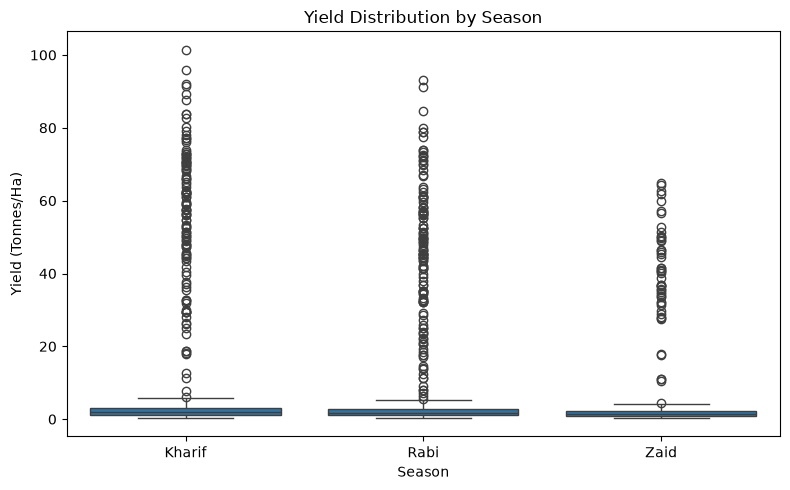

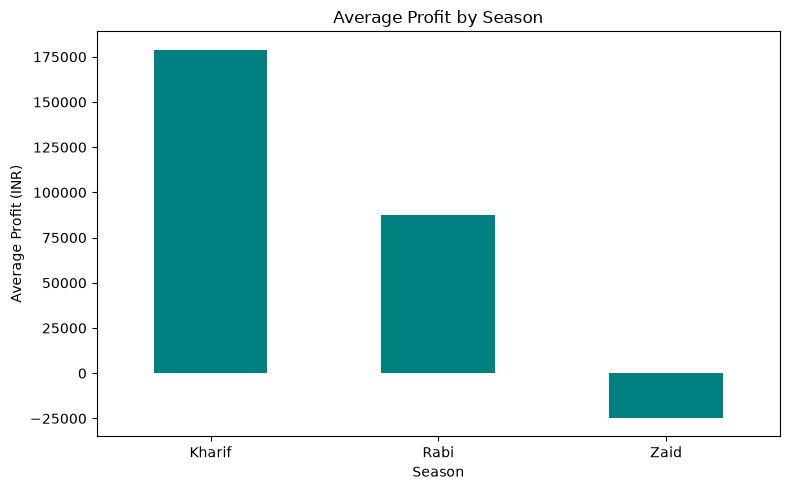

In [15]:
# Step 8: Seasonal Yield Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=clean, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

# Step 9: Average Profit by Season Bar Chart
profit_by_season = clean.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
profit_by_season.plot(kind="bar", color="teal")
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,Avg_Yield,Median_Yield,Avg_Profit,Profitability_Rate
Crop,,,,
Sugarcane,46.93,47.88,"817,187.99",88.52
Maize,2.72,2.84,"-83,978.33",36.30
Rice,2.44,2.46,"-102,213.50",33.62
Wheat,2.11,2.23,"-123,398.34",25.90
Chilli,1.54,1.56,"750,878.34",82.04
Groundnut,1.32,1.38,"44,858.12",59.20
Cotton,1.23,1.23,"124,546.92",65.35
Pulses,0.92,0.94,"-4,238.05",50.81


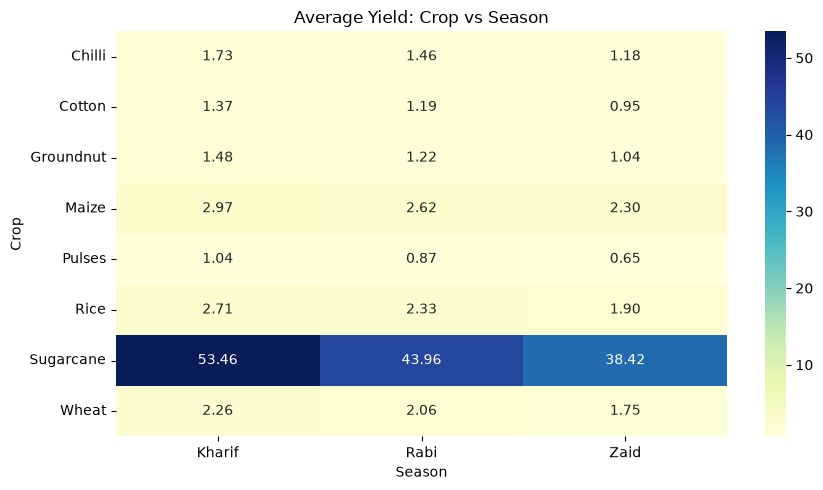

In [16]:
# Step 10: Crop Yield Summary
crop_summary = clean.groupby("Crop").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Avg_Profit=("Profit_INR", "mean"),
    Profitability_Rate=("Profit_INR", lambda x: (x > 0).mean() * 100)
).sort_values("Avg_Yield", ascending=False).round(2)

display(crop_summary)

# Step 11: Pivot Table & Heatmap (Crop vs Season Yield)
crop_season_yield = pd.pivot_table(
    clean, index="Crop", columns="Season", values="Yield_Tonnes_Ha", aggfunc="mean"
).round(2)

plt.figure(figsize=(9, 5))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield: Crop vs Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [17]:
# Step 12: Kruskal-Wallis Test for Non-parametric Distributions across Seasons
yield_groups = [clean.loc[clean["Season"] == season, "Yield_Tonnes_Ha"] for season in clean["Season"].unique()]
kw_yield = kruskal(*yield_groups)

profit_groups = [clean.loc[clean["Season"] == season, "Profit_INR"] for season in clean["Season"].unique()]
kw_profit = kruskal(*profit_groups)

print("Kruskal-Wallis Test Results:")
print(f"Yield  -> Statistic: {kw_yield.statistic:.4f}, p-value: {kw_yield.pvalue:.4e}")
print(f"Profit -> Statistic: {kw_profit.statistic:.4f}, p-value: {kw_profit.pvalue:.4e}")

# Step 13: Chi-Square Test of Independence (Season vs Profitability)
clean["Profitable"] = clean["Profit_INR"] > 0
contingency = pd.crosstab(clean["Season"], clean["Profitable"])
chi2, p_val, dof, _ = chi2_contingency(contingency)

print("\nChi-Square Test (Season vs Profitability):")
print(f"Chi2 Statistic: {chi2:.4f}, Degrees of Freedom: {dof}, p-value: {p_val:.4e}")

Kruskal-Wallis Test Results:
Yield  -> Statistic: 70.2646, p-value: 5.5237e-16
Profit -> Statistic: 101.9261, p-value: 7.3627e-23

Chi-Square Test (Season vs Profitability):
Chi2 Statistic: 92.6473, Degrees of Freedom: 2, p-value: 7.6188e-21


In [18]:
# Step 14: Detect outliers using IQR method
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for col in ["Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR", "Water_Efficiency_t_per_1000m3"]:
    if col in clean.columns:
        print(f"{col} Outliers (IQR Method): {iqr_outliers(clean[col])}")

Yield_Tonnes_Ha Outliers (IQR Method): 304
Production_Tonnes Outliers (IQR Method): 333
Profit_INR Outliers (IQR Method): 404
Water_Efficiency_t_per_1000m3 Outliers (IQR Method): 322
